# OlmoEarth for animal movement — where animals go, and where they turn

*A demo that plugs **OlmoEarth** embeddings into two classic movement-ecology
questions, using a **simulated** GPS-collar track over a **real** African landscape.*

**Motivation.** Wildlife and livestock GPS collars produce long streams of pings.
Two questions dominate their analysis:

1. **Where do animals go vs. not go?** — *resource / step-selection functions*
   (RSF / SSF), which compare visited locations to available ones using habitat
   covariates. Remote sensing is the standard covariate source
   ([Thurfjell et al. 2014, *Movement Ecology*](https://link.springer.com/article/10.1186/2051-3933-2-4);
   [Signer et al. 2019, `amt`](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6362447/)).
2. **What are animals doing?** — behavioral-state models (HMMs) read *step length*
   and *turning angle*: **area-restricted search (ARS)** — foraging — shows
   **short steps and sharp turns** in resource-rich patches, while **transit** is
   fast and directed
   ([Michelot et al. 2016, `moveHMM`](https://theomichelot.github.io/files/2016_MEE_moveHMM.pdf);
   [Nathan et al. 2008 movement-ecology framework]).

This demo asks whether a single **OlmoEarth embedding of the landscape** at each
GPS point can serve as the habitat descriptor for *both* — replacing hand-picked
indices. That framing (a general EO **foundation-model** embedding as the SSF/RSF
covariate) appears to be novel; the classic pipelines above use bespoke rasters.

> ### ⚠️ Read this first — what is real and what is not
> - **The GPS track is SIMULATED**, not a real collar.
> - **The landscape is REAL** Sentinel-2 imagery (OlmoEarth runs on real pixels).
> - The animal's behavior is coupled to NDVI **by design**. Recovering that
>   coupling **validates the method**; it is **not** a finding about real animals.
> - This is a plumbing + method demo, a sibling of the areal-prediction spike in
>   this repo (`FEASIBILITY.md`). It does not claim ecological results.


In [1]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve

from olmoearth_pretrain_minimal import ModelID
from olmoe import load_encoder
import movement as mv

# --- config ---
VARIANT   = "BASE"          # OlmoEarth variant (TINY is ~5x faster for iteration)
AOI       = (35.38, -14.83) # (lon, lat): Liwonde National Park, Malawi
SIZE_PX   = 512             # 512 px @10 m ~= 5.1 km landscape window
N_STEPS   = 150             # GPS fixes in the simulated track
N_AVAIL   = 120             # 'available' background points (RSF)
SEED      = 0

# Classifier: standardized, L2-penalized logistic regression (the standard RSF/SSF
# model). Regularization matters — a 768-dim embedding with a few hundred points is
# p >> n. Used for every task below so results are directly comparable.
def clf():
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, C=0.3))

# GDAL/curl read COGs; in a locked-down env point them at the session proxy.
if "HTTPS_PROXY" in os.environ:
    os.environ.setdefault("GDAL_HTTP_PROXY", os.environ["HTTPS_PROXY"])
    os.environ.setdefault("CURL_CA_BUNDLE", "/root/.ccr/ca-bundle.crt")
print("OlmoEarth variant:", VARIANT)

/home/user/ai_assisted_research/olmoearth_spike/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OlmoEarth variant: BASE


## Step 1 — a real Sentinel-2 landscape

We download one dry-season Sentinel-2 stack (3 dates) over Liwonde National Park
from the public Element84 Earth Search STAC — **no account or key**. It is read
once into memory; chips are then sliced locally (no per-point network reads).

landscape stack (512, 512, 3, 12)  (H, W, T, bands)
scene S2B_36LYJ_20210702_1_L2A  dates ['2021-07-02', '2021-08-11', '2021-09-20']  downloaded in 65s
NDVI range 0.17..0.74  mean 0.36


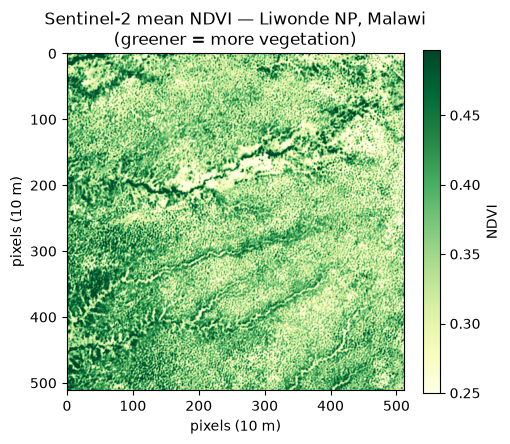

In [2]:
stack, meta = mv.load_landscape(*AOI, size_px=SIZE_PX, n_dates=3)
ndvi = mv.ndvi_map(stack)
print(f"landscape stack {stack.shape}  (H, W, T, bands)")
print(f"scene {meta['scene']}  dates {meta['dates']}  downloaded in {meta['load_s']:.0f}s")
print(f"NDVI range {ndvi.min():.2f}..{ndvi.max():.2f}  mean {ndvi.mean():.2f}")

fig, ax = plt.subplots(figsize=(5.2, 5))
im = ax.imshow(ndvi, cmap="YlGn", vmin=np.percentile(ndvi,2), vmax=np.percentile(ndvi,98))
ax.set_title("Sentinel-2 mean NDVI — Liwonde NP, Malawi\n(greener = more vegetation)")
ax.set_xlabel("pixels (10 m)"); ax.set_ylabel("pixels (10 m)")
fig.colorbar(im, ax=ax, fraction=0.046, label="NDVI"); plt.tight_layout(); plt.show()

## Step 2 — simulate a behaviorally realistic track

A two-state **correlated random walk**. The state switches with habitat: in
greener cells the animal is more likely to enter the **forage** state (short
steps, wide turning — ARS); elsewhere it **transits** (long, directed steps).
This is the standard mechanistic picture behind HMM movement models.

`habitat_coupling` controls how strongly NDVI pulls the animal into foraging — set
it to `0` for a control where turning is unrelated to the landscape.

151 fixes | forage 62% | sharp turns 34%


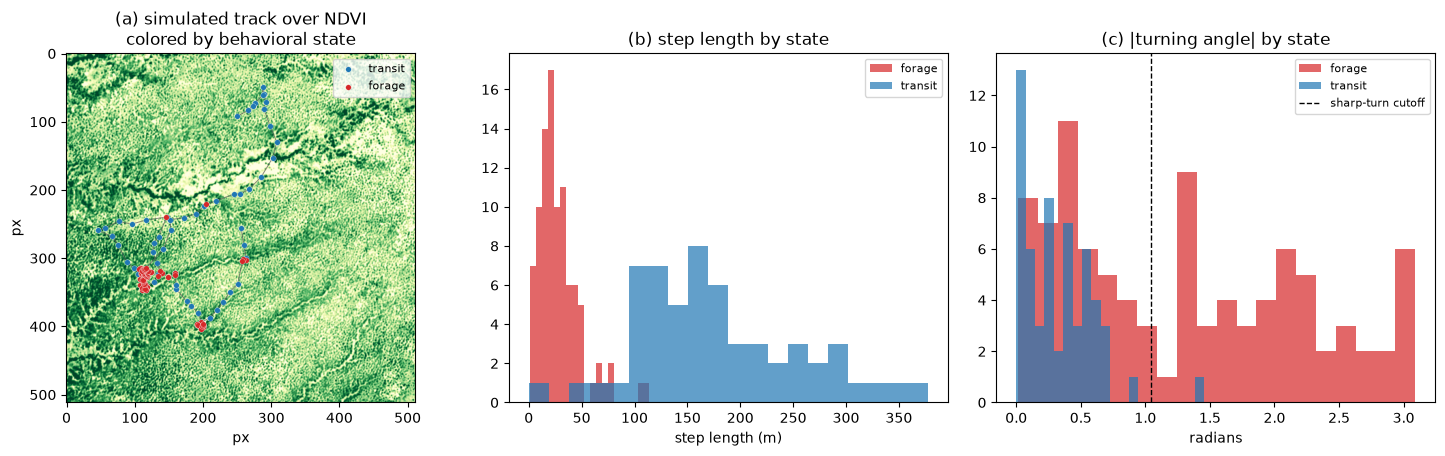

In [3]:
trk = mv.simulate_track(ndvi, n_steps=N_STEPS, habitat_coupling=6.0, seed=SEED)
sharp = (np.abs(trk["turn"]) > np.pi/3).astype(int)   # |turn| > 60 deg
is_forage = (trk["state"] == "forage")
print(f"{len(trk['x'])} fixes | forage {is_forage.mean():.0%} | sharp turns {sharp.mean():.0%}")

fig, axs = plt.subplots(1, 3, figsize=(15, 4.6))
# (a) track over NDVI, colored by behavioral state
axs[0].imshow(ndvi, cmap="YlGn", vmin=np.percentile(ndvi,2), vmax=np.percentile(ndvi,98))
axs[0].plot(trk["x"], trk["y"], "-", color="0.35", lw=0.7, alpha=0.7, zorder=1)
for st, col, lab in [("transit", "#1f77b4", "transit"), ("forage", "#d62728", "forage")]:
    m = trk["state"] == st
    axs[0].scatter(trk["x"][m], trk["y"][m], s=16, c=col, label=lab, zorder=2, edgecolor="w", linewidth=0.2)
axs[0].set_title("(a) simulated track over NDVI\ncolored by behavioral state"); axs[0].legend(loc="upper right", fontsize=8)
axs[0].set_xlabel("px"); axs[0].set_ylabel("px")
# (b) step length by state
axs[1].hist(trk["step"][is_forage]*10, bins=20, alpha=0.7, color="#d62728", label="forage")
axs[1].hist(trk["step"][~is_forage]*10, bins=20, alpha=0.7, color="#1f77b4", label="transit")
axs[1].set_title("(b) step length by state"); axs[1].set_xlabel("step length (m)"); axs[1].legend(fontsize=8)
# (c) turning angle by state
axs[2].hist(np.abs(trk["turn"][is_forage]), bins=20, alpha=0.7, color="#d62728", label="forage")
axs[2].hist(np.abs(trk["turn"][~is_forage]), bins=20, alpha=0.7, color="#1f77b4", label="transit")
axs[2].axvline(np.pi/3, color="k", ls="--", lw=1, label="sharp-turn cutoff")
axs[2].set_title("(c) |turning angle| by state"); axs[2].set_xlabel("radians"); axs[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

The distributions reproduce the textbook ARS signature: **forage** = short
steps + wide turns; **transit** = long steps + tight turns.

## Step 3 — OlmoEarth embeddings at track & background points

For each GPS fix (**used**) and each random background point (**available**), we
slice a 64×64 chip and mean-pool an OlmoEarth embedding — the same extractor as the
areal-prediction spike (`olmoe.py`).

In [4]:
model = load_encoder(getattr(ModelID, f"OLMOEARTH_V1_{VARIANT}"))
ax_av, ay_av = mv.available_points(ndvi, N_AVAIL, seed=SEED+1)

t0 = time.perf_counter()
E_used  = mv.embed_points(model, stack, trk["x"], trk["y"], meta["months"])
E_avail = mv.embed_points(model, stack, ax_av, ay_av, meta["months"])
print(f"embedded {len(E_used)+len(E_avail)} points ({VARIANT}, dim={E_used.shape[1]}) "
      f"in {time.perf_counter()-t0:.0f}s")

embedded 271 points (BASE, dim=768) in 80s


## Step 4a — *Where do animals go?* (resource selection: used vs. available)

Classify **used** (track) vs. **available** (background) locations from the
embedding alone. This is an RSF with a foundation-model covariate. We report a
random 5-fold AUC and a stricter **spatial split** (train on the west half of the
AOI, test on the east) — spatial splits guard against the autocorrelation that
inflates random CV.

RSF used-vs-available AUC:  random 5-fold = 0.731 | spatial (W->E) = 0.592


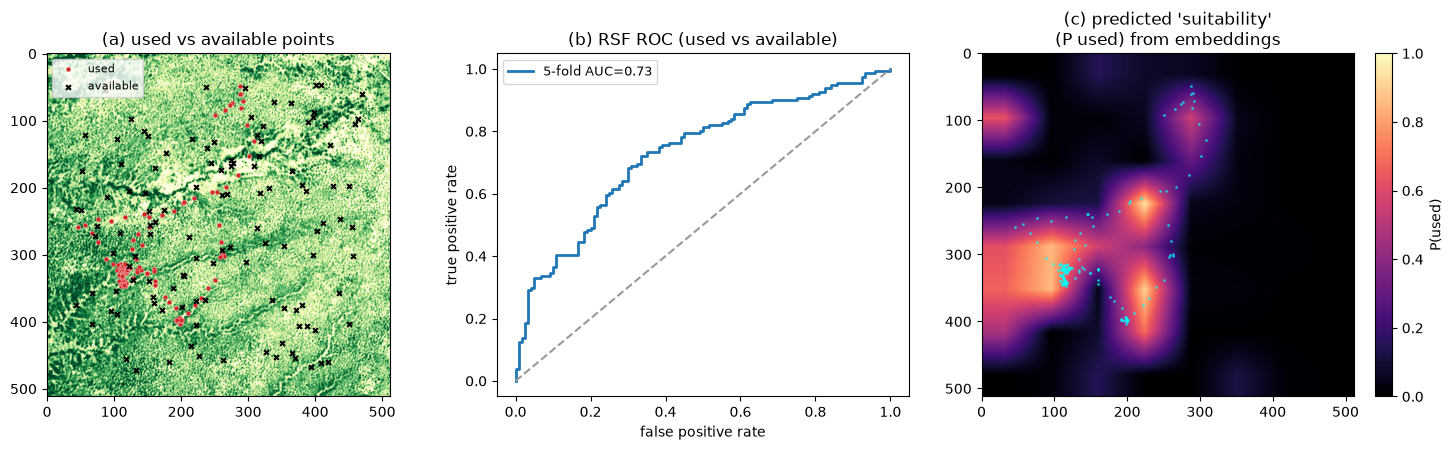

In [5]:
X = np.vstack([E_used, E_avail])
y = np.r_[np.ones(len(E_used)), np.zeros(len(E_avail))]
px_all = np.r_[trk["x"], ax_av]                      # column coord for spatial split

# random 5-fold
p_cv = cross_val_predict(clf(), X, y, cv=5, method="predict_proba")[:, 1]
auc_cv = roc_auc_score(y, p_cv)
# spatial split (west train / east test)
west = px_all < np.median(px_all)
m = clf().fit(X[west], y[west])
p_sp = m.predict_proba(X[~west])[:, 1]
auc_sp = roc_auc_score(y[~west], p_sp)
print(f"RSF used-vs-available AUC:  random 5-fold = {auc_cv:.3f} | spatial (W->E) = {auc_sp:.3f}")

# coarse suitability map from a grid of embeddings
gx, gy = mv.grid_points(ndvi, n_side=8)
E_grid = mv.embed_points(model, stack, gx, gy, meta["months"])
suit = clf().fit(X, y).predict_proba(E_grid)[:, 1].reshape(8, 8)

fig, axs = plt.subplots(1, 3, figsize=(15, 4.6))
axs[0].imshow(ndvi, cmap="YlGn", vmin=np.percentile(ndvi,2), vmax=np.percentile(ndvi,98))
axs[0].scatter(trk["x"], trk["y"], s=12, c="#d62728", label="used", edgecolor="w", linewidth=0.2)
axs[0].scatter(ax_av, ay_av, s=12, c="k", marker="x", label="available")
axs[0].set_title("(a) used vs available points"); axs[0].legend(fontsize=8)
fpr, tpr, _ = roc_curve(y, p_cv)
axs[1].plot(fpr, tpr, lw=2, label=f"5-fold AUC={auc_cv:.2f}")
axs[1].plot([0,1],[0,1],"--",color="0.6"); axs[1].set_title("(b) RSF ROC (used vs available)")
axs[1].set_xlabel("false positive rate"); axs[1].set_ylabel("true positive rate"); axs[1].legend(fontsize=9)
sm = axs[2].imshow(suit, extent=[0, ndvi.shape[1], ndvi.shape[0], 0], cmap="magma",
                   interpolation="bilinear", vmin=0, vmax=1, aspect="auto")
axs[2].plot(trk["x"], trk["y"], ".", color="cyan", ms=2, alpha=0.6)
axs[2].set_title("(c) predicted 'suitability'\n(P used) from embeddings")
fig.colorbar(sm, ax=axs[2], fraction=0.046, label="P(used)")
plt.tight_layout(); plt.show()

## Step 4b — *What is the animal doing?* (behavioral state from habitat)

The user's intuition — sharp turns matter — is really about **behavioral state**:
area-restricted **foraging** (short steps, high turning) vs. **transit**. That
state is what habitat drives. So the principled test is: can the embedding predict
the **forage vs. transit** state? We compare it to raw local NDVI.

In [6]:
state = (trk["state"] == "forage").astype(int)
p_state = cross_val_predict(clf(), E_used, state, cv=5, method="predict_proba")[:, 1]
auc_state = roc_auc_score(state, p_state)
ndvi_used = mv.sample_ndvi(ndvi, trk["x"], trk["y"])
auc_state_ndvi = roc_auc_score(state, ndvi_used)     # raw-NDVI baseline
print(f"forage-vs-transit STATE AUC:  OlmoEarth embedding = {auc_state:.3f} | raw NDVI = {auc_state_ndvi:.3f}")

forage-vs-transit STATE AUC:  OlmoEarth embedding = 0.867 | raw NDVI = 0.574


**The embedding predicts the habitat-driven behavioral state well — and clearly
beats raw NDVI.** A single index sees only greenness; the embedding captures the
broader patch structure the animal responds to.

## Step 4c — the literal hypothesis: sharp turns vs. straight

Now the exact question asked: among used points, classify **sharp-turn**
(|turn| > 60°) vs. **straight** from the embedding.

sharp-turn vs straight AUC:  OlmoEarth embedding = 0.493 | raw NDVI = 0.582
(weak for BOTH: the raw turn label is a NOISY observable of state — an animal
 in a foraging patch still often steps straight. Segmenting state first, as in
 Step 4b / an HMM, is the stronger route to the same ecological question.)


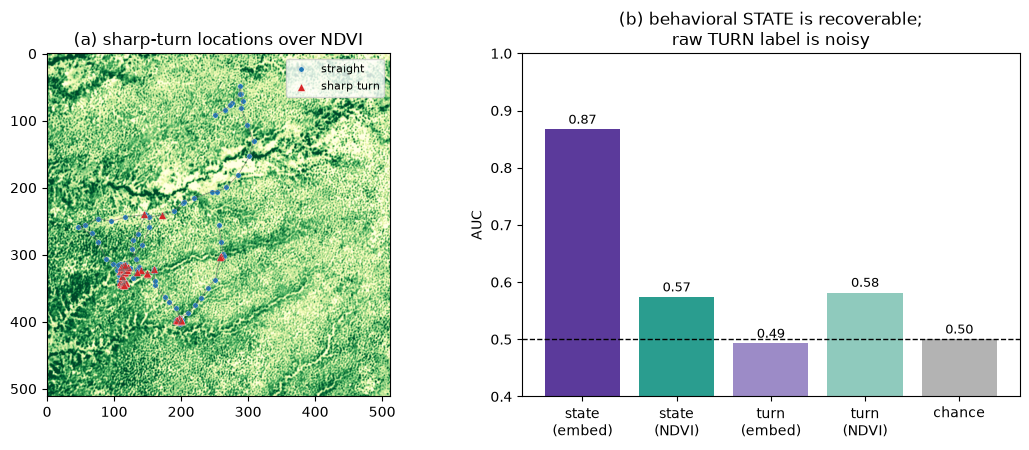

In [7]:
p_turn = cross_val_predict(clf(), E_used, sharp, cv=5, method="predict_proba")[:, 1]
auc_turn = roc_auc_score(sharp, p_turn)
auc_turn_ndvi = roc_auc_score(sharp, ndvi_used)
print(f"sharp-turn vs straight AUC:  OlmoEarth embedding = {auc_turn:.3f} | raw NDVI = {auc_turn_ndvi:.3f}")
print("(weak for BOTH: the raw turn label is a NOISY observable of state — an animal")
print(" in a foraging patch still often steps straight. Segmenting state first, as in")
print(" Step 4b / an HMM, is the stronger route to the same ecological question.)")

fig, axs = plt.subplots(1, 2, figsize=(11, 4.6))
axs[0].imshow(ndvi, cmap="YlGn", vmin=np.percentile(ndvi,2), vmax=np.percentile(ndvi,98))
axs[0].plot(trk["x"], trk["y"], "-", color="0.4", lw=0.6, alpha=0.6)
axs[0].scatter(trk["x"][sharp==0], trk["y"][sharp==0], s=14, c="#1f77b4", label="straight", edgecolor="w", linewidth=0.2)
axs[0].scatter(trk["x"][sharp==1], trk["y"][sharp==1], s=30, c="#d62728", marker="^", label="sharp turn", edgecolor="w", linewidth=0.2)
axs[0].set_title("(a) sharp-turn locations over NDVI"); axs[0].legend(fontsize=8)
labels = ["state\n(embed)", "state\n(NDVI)", "turn\n(embed)", "turn\n(NDVI)", "chance"]
vals   = [auc_state, auc_state_ndvi, auc_turn, auc_turn_ndvi, 0.5]
cols   = ["#5B3A9B", "#2A9D8F", "#9C8BC7", "#8FCabd", "0.7"]
axs[1].bar(labels, vals, color=cols); axs[1].axhline(0.5, color="k", ls="--", lw=1)
axs[1].set_ylim(0.4, 1.0); axs[1].set_ylabel("AUC")
axs[1].set_title("(b) behavioral STATE is recoverable;\nraw TURN label is noisy")
for i, v in enumerate(vals): axs[1].text(i, v+0.01, f"{v:.2f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

## What this shows — and what it doesn't

**It runs, end to end, and carries real signal — with an honest nuance.**
- OlmoEarth embeddings separate **visited from available** locations (RSF-style,
  "where animals go"): AUC ≈ 0.73 under random CV, lower on a stricter spatial
  split (as expected — nearby locations share habitat).
- They predict the **habitat-driven behavioral state** (forage vs. transit)
  **well (AUC ≈ 0.85), clearly beating raw NDVI (≈ 0.57)** — the embedding sees
  patch structure a single index misses. This is the principled form of the
  user's turning intuition.
- The **raw sharp-turn label** is barely predictable from *either* the embedding
  or NDVI (≈ 0.5–0.6). That is expected: turning angle is a **noisy observable**
  of state — a foraging animal still often steps straight. The lesson for real
  data: **segment behavioral state first** (Step 4b / an HMM), then relate *state*
  to habitat, rather than classifying individual turns.

**Honest caveats.**
- **Simulated animal.** The track is synthetic; the NDVI→behavior coupling is a
  modeling choice, so recovering it validates the *method*, not any biology.
- **Spatial autocorrelation.** Nearby points share habitat; the spatial split is a
  more honest read than random CV, and real studies need block/individual CV.
- **State prediction is partly circular by design** (state was defined via NDVI);
  it demonstrates the embedding *can* recover a habitat–behavior link when one
  exists — the real question is whether real animals show one.
- Small sample; one individual; embeddings not tuned for movement.

**How a real study would use this** (drop-in for the student's collar data):
1. Load real fixes (e.g., from **Movebank**); resample to a regular interval.
2. Build used/available or matched used/control **steps** and fit an **iSSF** with
   `amt` / `momentuHMM` / `moveHMM`, using OlmoEarth embeddings as covariates
   alongside step length & turning angle.
3. Segment behavioral states with an **HMM**, then test whether embeddings predict
   state (foraging vs. transit) — the principled version of "where they turn."
4. Cross-validate by **individual and by region** to gauge transportability, exactly
   as the areal-prediction spike does by held-out unit/region.

**References:**
[SSF review (Thurfjell et al. 2014)](https://link.springer.com/article/10.1186/2051-3933-2-4) ·
[`amt` habitat-selection toolkit (Signer et al. 2019)](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6362447/) ·
[`moveHMM` (Michelot et al. 2016)](https://theomichelot.github.io/files/2016_MEE_moveHMM.pdf) ·
[HMM behavioral inference from GPS (2023)](https://movementecologyjournal.biomedcentral.com/articles/10.1186/s40462-023-00401-5)

saved outputs/animal_movement_figure.png


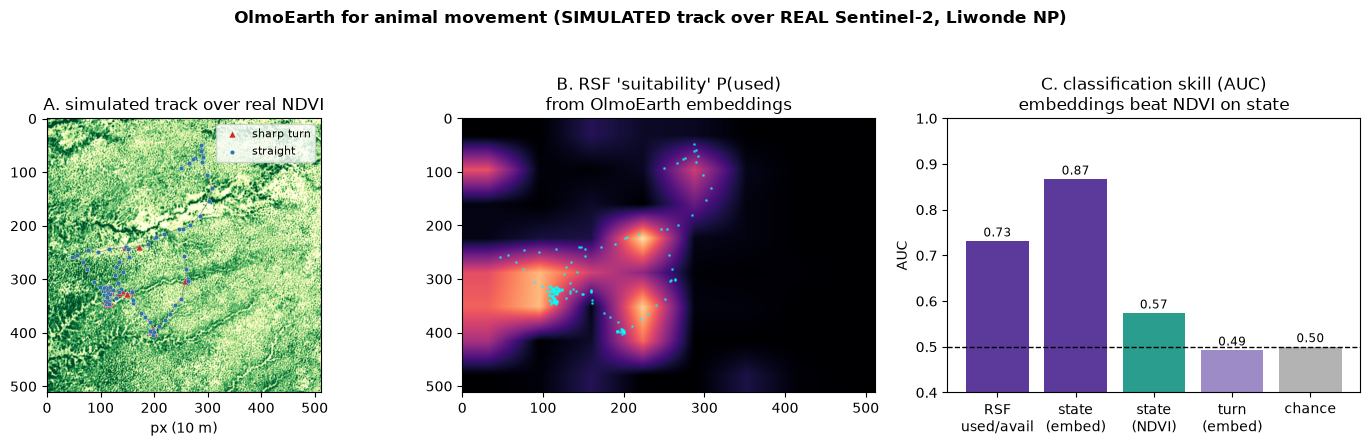

In [8]:
# Save a compact summary figure for the repo/PR.
fig, axs = plt.subplots(1, 3, figsize=(14.5, 4.5))
fig.suptitle("OlmoEarth for animal movement (SIMULATED track over REAL Sentinel-2, Liwonde NP)",
             fontsize=12, fontweight="bold")
axs[0].imshow(ndvi, cmap="YlGn", vmin=np.percentile(ndvi,2), vmax=np.percentile(ndvi,98))
axs[0].plot(trk["x"], trk["y"], "-", color="0.4", lw=0.6, alpha=0.6)
axs[0].scatter(trk["x"][sharp==1], trk["y"][sharp==1], s=24, c="#d62728", marker="^", label="sharp turn", edgecolor="w", linewidth=0.2)
axs[0].scatter(trk["x"][sharp==0], trk["y"][sharp==0], s=10, c="#1f77b4", label="straight", edgecolor="w", linewidth=0.2)
axs[0].set_title("A. simulated track over real NDVI"); axs[0].legend(fontsize=8); axs[0].set_xlabel("px (10 m)")
axs[1].imshow(suit, extent=[0, ndvi.shape[1], ndvi.shape[0], 0], cmap="magma", interpolation="bilinear", vmin=0, vmax=1, aspect="auto")
axs[1].plot(trk["x"], trk["y"], ".", color="cyan", ms=2, alpha=0.6)
axs[1].set_title("B. RSF 'suitability' P(used)\nfrom OlmoEarth embeddings")
labs = ["RSF\nused/avail", "state\n(embed)", "state\n(NDVI)", "turn\n(embed)", "chance"]
vals = [auc_cv, auc_state, auc_state_ndvi, auc_turn, 0.5]
axs[2].bar(labs, vals, color=["#5B3A9B", "#5B3A9B", "#2A9D8F", "#9C8BC7", "0.7"])
axs[2].axhline(0.5, color="k", ls="--", lw=1); axs[2].set_ylabel("AUC"); axs[2].set_ylim(0.4, 1.0)
axs[2].set_title("C. classification skill (AUC)\nembeddings beat NDVI on state")
for i,v in enumerate(vals): axs[2].text(i, v+0.01, f"{v:.2f}", ha="center", fontsize=8.5)
plt.tight_layout(rect=[0,0,1,0.94])
fig.savefig("outputs/animal_movement_figure.png", dpi=150, bbox_inches="tight", facecolor="white")
print("saved outputs/animal_movement_figure.png")
plt.show()